# Home Credit Default Risk - Credit Risk Model

Notebook ini membangun model prediksi **credit default** untuk proses approval kredit Home Credit, dengan dua versi model: 
1. **Logistic Regression** (baseline interpretable)
2. **LightGBM** (boosting).

Alur notebook:
1. Load data
2. EDA
3. Feature engineering
4. Logistic Regression
5. LightGBM
6. Evaluasi
7. Reason codes berbasis SHAP
8. Kesimpulan

Logika inti dipisah ke modul di folder `src/` supaya notebook dan `credit_risk_model.py` (inference) memakai kode yang sama (hasil konsisten, tidak ada duplikasi).

## Setup dan load data

Import library dan modul lokal. Semua path relatif ke folder proyek.

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.metrics import roc_curve
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

In [2]:
BASE = Path.cwd()
DATA_DIR = BASE / "data"

# Menambahkan path ke sys.path agar src bisa menemukan modul yang ada di folder src
sys.path.append(str(BASE)) 

In [3]:
from src import features as F
from src import modeling as M
from src import reason_codes as RC

Kita baca tabel utama `application_train.csv` untuk EDA. Tabel ini yang berisi kolom `TARGET`.

In [4]:
app = pd.read_csv(DATA_DIR / "application_train.csv")

In [5]:
app.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Non-Null Count   Dtype  
---   ------                        --------------   -----  
 0    SK_ID_CURR                    307511 non-null  int64  
 1    TARGET                        307511 non-null  int64  
 2    NAME_CONTRACT_TYPE            307511 non-null  object 
 3    CODE_GENDER                   307511 non-null  object 
 4    FLAG_OWN_CAR                  307511 non-null  object 
 5    FLAG_OWN_REALTY               307511 non-null  object 
 6    CNT_CHILDREN                  307511 non-null  int64  
 7    AMT_INCOME_TOTAL              307511 non-null  float64
 8    AMT_CREDIT                    307511 non-null  float64
 9    AMT_ANNUITY                   307499 non-null  float64
 10   AMT_GOODS_PRICE               307233 non-null  float64
 11   NAME_TYPE_SUITE               306219 non-null  object 
 12   NAME_INCOME_TYPE            

In [6]:
print("Shape:", app.shape)

Shape: (307511, 122)


In [7]:
app[["SK_ID_CURR", "TARGET", "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "DAYS_BIRTH", "EXT_SOURCE_2"]].head()

,SK_ID_CURR,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,DAYS_BIRTH,EXT_SOURCE_2
0,100002,1,202500.0,406597.5,24700.5,-9461,0.262949
1,100003,0,270000.0,1293502.5,35698.5,-16765,0.622246
2,100004,0,67500.0,135000.0,6750.0,-19046,0.555912
3,100006,0,135000.0,312682.5,29686.5,-19005,0.650442
4,100007,0,121500.0,513000.0,21865.5,-19932,0.322738


In [8]:
app.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


## EDA

### Duplikat baris

Dicek sebelum split supaya baris identik tidak bocor ke train dan test sekaligus. Selain duplikat penuh, `SK_ID_CURR` diperiksa karena seharusnya unik (primary key).

In [9]:
print("Baris duplikat penuh:", app.duplicated().sum())
print("SK_ID_CURR duplikat (primary key):", app["SK_ID_CURR"].duplicated().sum())

Baris duplikat penuh: 0
SK_ID_CURR duplikat (primary key): 0


Hasil: 0 duplikat penuh dan 0 ID ganda. Dataset bersih, tidak ada baris yang perlu dibuang.

### Missing values

Kita lihat kolom dengan missing tertinggi untuk memutuskan strategi imputasi.

In [10]:
miss = app.isna().mean().sort_values(ascending=False)
miss_top = miss[miss > 0].head(60) * 100
print(miss_top.round(1).astype(str) + " %")

COMMONAREA_AVG                  69.9 %
COMMONAREA_MODE                 69.9 %
COMMONAREA_MEDI                 69.9 %
NONLIVINGAPARTMENTS_MEDI        69.4 %
NONLIVINGAPARTMENTS_MODE        69.4 %
NONLIVINGAPARTMENTS_AVG         69.4 %
FONDKAPREMONT_MODE              68.4 %
LIVINGAPARTMENTS_AVG            68.4 %
LIVINGAPARTMENTS_MEDI           68.4 %
LIVINGAPARTMENTS_MODE           68.4 %
FLOORSMIN_MODE                  67.8 %
FLOORSMIN_AVG                   67.8 %
FLOORSMIN_MEDI                  67.8 %
YEARS_BUILD_AVG                 66.5 %
YEARS_BUILD_MODE                66.5 %
YEARS_BUILD_MEDI                66.5 %
OWN_CAR_AGE                     66.0 %
LANDAREA_MEDI                   59.4 %
LANDAREA_AVG                    59.4 %
LANDAREA_MODE                   59.4 %
BASEMENTAREA_MODE               58.5 %
BASEMENTAREA_MEDI               58.5 %
BASEMENTAREA_AVG                58.5 %
EXT_SOURCE_1                    56.4 %
NONLIVINGAREA_MODE              55.2 %
NONLIVINGAREA_AVG        

Kolom info gedung (`..._AVG/MODE/MEDI`), `OWN_CAR_AGE`, dan `EXT_SOURCE_1` paling banyak kosong. LightGBM menangani NaN secara native; untuk Logistic Regression kita imputasi median.

### Distribusi target

Hal pertama yang menentukan seluruh strategi: seberapa timpang kelasnya.

TARGET
0    282686
1     24825
Name: count, dtype: int64
Default rate: 8.07%


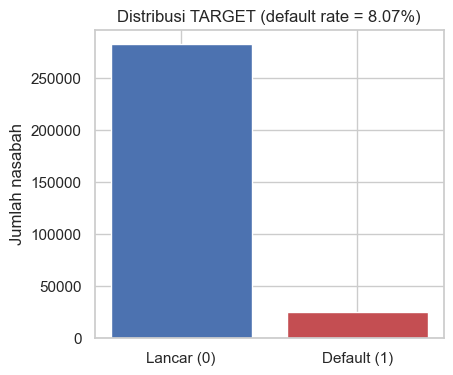

In [11]:
target_counts = app["TARGET"].value_counts().sort_index()
default_rate = app["TARGET"].mean()
print(target_counts)
print(f"Default rate: {default_rate*100:.2f}%")

plt.figure(figsize=(4.5, 4))
plt.bar(["Lancar (0)", "Default (1)"], target_counts.values, color=["#4c72b0", "#c44e52"])
plt.title(f"Distribusi TARGET (default rate = {default_rate*100:.2f}%)")
plt.ylabel("Jumlah nasabah")
plt.show()

Default rate cuma sekitar 8% (sekitar 24.800 default dari 307.511 nasabah), jadi kelasnya sangat timpang. Akibatnya accuracy menyesatkan: Accuracy membengkak karena didominasi kelas mayoritas (lancar).

 Precision/recall memfokuskan penilaian ke kelas default (recall menekan false negative, precision menekan false positive), tapi keduanya terikat pada satu threshold. Karena itu metrik utama kita **AUC-ROC**, yang menilai seberapa baik model mengurutkan risiko di semua threshold sekaligus (0,5 = asal tebak, 1,0 = sempurna) dan tidak menggelembung oleh kelas mayoritas.

### Skor eksternal vs target

`EXT_SOURCE_1/2/3` dikenal paling prediktif. Kita cek korelasinya dengan target.

EXT_SOURCE_1: korelasi dengan TARGET = -0.1553

EXT_SOURCE_2: korelasi dengan TARGET = -0.1605
EXT_SOURCE_3: korelasi dengan TARGET = -0.1789


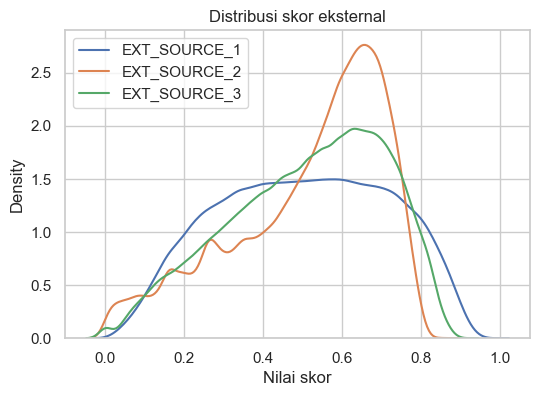

In [12]:
for c in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]:
    corr = app[[c, "TARGET"]].dropna().corr().iloc[0, 1]
    print(f"{c}: korelasi dengan TARGET = {corr:.4f}")

plt.figure(figsize=(6, 4))
for c in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]:
    sns.kdeplot(data=app, x=c, label=c)
plt.title("Distribusi skor eksternal")
plt.xlabel("Nilai skor")
plt.legend()
plt.show()

Tandanya negatif (korelasi negatif): saat skor eksternal naik, TARGET cenderung turun menuju 0. TARGET turun ke 0 artinya nasabah cenderung lancar, bukan default.

Jadi makin tinggi skor eksternal, makin kecil kemungkinan default. Ini konsisten dengan intuisi kredit (skor bagus = risiko rendah).

### Anomali DAYS_EMPLOYED

Nilai `365243` (~1000 tahun) adalah kode untuk pensiun/tidak bekerja, bukan data riil.

In [13]:
print("Jumlah baris DAYS_EMPLOYED == 365243:", (app["DAYS_EMPLOYED"] == 365243).sum())
print("Default rate kelompok anomali:", (app.loc[app["DAYS_EMPLOYED"] == 365243, "TARGET"].mean() * 100).round(2), "%")
print("Default rate kelompok normal :", (app.loc[app["DAYS_EMPLOYED"] != 365243, "TARGET"].mean() * 100).round(2), "%")

Jumlah baris DAYS_EMPLOYED == 365243: 55374
Default rate kelompok anomali: 5.4 %
Default rate kelompok normal : 8.66 %


### Rasio bisnis vs default

Rasio cicilan terhadap penghasilan (DTI - Debt-to-Income) adalah ukuran beban bayar. Kita cek apakah DTI lebih tinggi pada nasabah default.

In [14]:
tmp = app.copy()
tmp["ANNUITY_INCOME_RATIO"] = tmp["AMT_ANNUITY"] / tmp["AMT_INCOME_TOTAL"]
print(tmp.groupby("TARGET")["ANNUITY_INCOME_RATIO"].median().round(4))

TARGET
0    0.1623
1    0.1693
Name: ANNUITY_INCOME_RATIO, dtype: float64


Interpretasi: 
- Peminjam yang gagal bayar, rata-rata punya beban cicilan sedikit lebih tinggi terhadap pendapatannya (16.9% vs 16.2%). 
- Arahnya masuk akal (beban makin berat → risiko gagal bayar naik), tapi selisihnya sangat kecil (~0.7 poin persen), jadi fitur ini sinyalnya lemah kalau berdiri sendiri.

### Konsistensi kategorikal & placeholder tersembunyi

Placeholder seperti `'XNA'` terbaca sebagai kategori biasa, jadi harus dicari dan diputuskan perlakuannya. Whitespace tepi (`'Male '` vs `'Male'`) juga dicek karena membuat satu kategori terpecah dua.

In [15]:
for c in ["CODE_GENDER", "ORGANIZATION_TYPE"]:
    print(f"{c}: unik={app[c].nunique()}, 'XNA'={(app[c] == 'XNA').sum()}")
obj_cols = app.select_dtypes("object").columns
ws = {c: int((app[c].astype(str).str.strip() != app[c].astype(str)).sum()) for c in obj_cols}
print("Kolom dengan whitespace tepi:", {k: v for k, v in ws.items() if v})

CODE_GENDER: unik=3, 'XNA'=4
ORGANIZATION_TYPE: unik=58, 'XNA'=55374


Kolom dengan whitespace tepi: {}


`CODE_GENDER` punya 4 nilai `'XNA'` yang diperlakukan sebagai missing di `F.clean_application`.

 `ORGANIZATION_TYPE` punya banyak `'XNA'`, tapi di sini artinya 'tidak tersedia' yang valid, dibiarkan sebagai kategori dan ditangani native oleh LightGBM. 
 

Tidak ada whitespace tepi.

### Infinity & nilai mustahil

In [16]:
num = app.select_dtypes("number")
print("Kolom mengandung inf:", int(np.isinf(num).sum().sum()))
print("CODE_GENDER == 'XNA':", int((app["CODE_GENDER"] == "XNA").sum()))
print("DAYS_EMPLOYED == 365243 (sentinel):", int((app["DAYS_EMPLOYED"] == 365243).sum()))

Kolom mengandung inf: 0
CODE_GENDER == 'XNA': 4
DAYS_EMPLOYED == 365243 (sentinel): 55374


Tidak ada `inf` di data mentah (rasio turunan yang bisa memunculkan `inf` dibersihkan jadi NaN di `F.build_features`). 

Sentinel `DAYS_EMPLOYED` (sudah dibahas di 2.4) dan `'XNA'` gender adalah kode/anomali, bukan nilai nyata, ditangani saat cleaning. Kolom `DAYS_*` bernilai negatif memang by design (relatif terhadap hari aplikasi), jadi bukan nilai mustahil.

### Kolom konstan / ID / high-cardinality

Kolom konstan tidak memberi sinyal, kolom ID membuat overfit dan membocorkan identitas baris, dan kategori high-cardinality tidak boleh di-one-hot (meledak lebar).

In [17]:
nun = app.nunique()
print("Kolom konstan:", nun[nun <= 1].index.tolist())
print("Kolom ID-like (>95% unik):", (nun / len(app))[lambda s: s > 0.95].index.tolist())
highcard = {c: app[c].nunique() for c in app.select_dtypes("object") if app[c].nunique() > 50}
print("Object high-cardinality (>50):", highcard)

Kolom konstan: []
Kolom ID-like (>95% unik): ['SK_ID_CURR']
Object high-cardinality (>50): {'ORGANIZATION_TYPE': 58}


Tidak ada kolom konstan. 

`SK_ID_CURR` murni ID, di-drop di `F.get_lgbm_features` dan tidak dipakai sebagai fitur. 

`ORGANIZATION_TYPE` high-cardinality (58 nilai), jadi tidak di-one-hot; dibiarkan sebagai kategori native LightGBM dan tidak masuk subset interpretable LogReg.

### Outlier & skewness (kolom monetari)

Kolom uang biasanya skewed. Dideteksi dulu (rentang + skew), jangan auto-buang, karena nilai ekstrem bisa jadi sinyal riil.

In [18]:
money = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"]
desc = app[money].describe().T[["min", "50%", "max"]]
desc["skew"] = app[money].skew()
print(desc.round(0))

                      min       50%          max   skew
AMT_INCOME_TOTAL  25650.0  147150.0  117000000.0  392.0
AMT_CREDIT        45000.0  513531.0    4050000.0    1.0
AMT_ANNUITY        1616.0   24903.0     258026.0    2.0
AMT_GOODS_PRICE   40500.0  450000.0    4050000.0    1.0


`AMT_INCOME_TOTAL` sangat skewed (max ~117 juta vs median ~147 ribu, skew ~392); sisanya skew 1.2-1.6.

 Keputusan: outlier tidak dibuang.

LightGBM tahan outlier, dan untuk LogReg beban bayar dinyatakan sebagai rasio (mis. `ANNUITY_INCOME_RATIO`) lalu di-`StandardScaler`, jadi nilai yg skewed tidak dipakai langsung. Konsisten dengan `F.clean_application` yang sengaja tidak membuang pendapatan ekstrem.

## Feature engineering

Fitur tidak dibuat sekaligus lewat satu pemanggilan fungsi. Untuk tiap kelompok fitur kita lihat dulu sinyalnya ke `TARGET`, supaya alasan bisnis tiap fitur terlihat.

Kelompok fitur dari tabel `application` sudah kita amati di EDA: rasio DTI, skor eksternal, dan anomali `DAYS_EMPLOYED`.

Di sini kita periksa dulu 3 tabel pendukung (`bureau`, `previous_application`, `installments_payments`) yang belum dilihat, baru semua sinyal dirakit jadi tabel fitur final.

### Sinyal dari tabel `application`

Section 2 sudah menunjukkan tiga sinyal utama dari `application`: 
- DTI (`ANNUITY_INCOME_RATIO`) menaikkan default rate
- skor eksternal `EXT_SOURCE_*` berkorelasi negatif dengan default 
- sentinel `DAYS_EMPLOYED == 365243` perlu ditandai.

Rasio kemampuan/beban bayar lain (`CREDIT_INCOME_RATIO`, `CREDIT_GOODS_RATIO`, `CREDIT_TERM`, `INCOME_PER_PERSON`) mengikuti logika ability-to-pay yang sama.

Semua ini dikonsolidasi di `F.add_application_business_features` dan `F.clean_application`.

### Sinyal dari `bureau` (biro kredit eksternal)

Dugaan bisnis: nasabah yang punya catatan tunggakan di biro kredit lebih berisiko default. Kita cek dengan menghitung jumlah kredit yang pernah menunggak per nasabah, lalu lihat default rate-nya. Kalau naik seiring jumlah tunggakan, fitur ini layak dibuat.

In [19]:
buro = pd.read_csv(DATA_DIR / "bureau.csv",
                   usecols=["SK_ID_CURR", "CREDIT_ACTIVE", "CREDIT_DAY_OVERDUE"])
buro["HAS_OVERDUE"] = (buro["CREDIT_DAY_OVERDUE"] > 0).astype(int)
overdue = buro.groupby("SK_ID_CURR")["HAS_OVERDUE"].sum().rename("BURO_OVERDUE_COUNT")
chk = app[["SK_ID_CURR", "TARGET"]].merge(overdue, on="SK_ID_CURR", how="inner")
chk["overdue_grp"] = chk["BURO_OVERDUE_COUNT"].clip(upper=3)
print("Default rate per jumlah kredit menunggak di biro (0..3+):")
print(chk.groupby("overdue_grp")["TARGET"].mean().round(4))

Default rate per jumlah kredit menunggak di biro (0..3+):
overdue_grp
0    0.0762
1    0.1448
2    0.2883
3    0.5789
Name: TARGET, dtype: float64


Default rate naik tajam seiring jumlah tunggakan (sekitar 8% -> 58% pada 3+ tunggakan).

Sinyal jelas, maka `F.aggregate_bureau` meringkas riwayat biro jadi fitur seperti `BURO_OVERDUE_COUNT`, `BURO_ACTIVE_COUNT`, dan utilisasi utang `BURO_DEBT_CREDIT_RATIO`.

### Sinyal dari `previous_application`

Dugaan bisnis: nasabah yang aplikasi kreditnya sering ditolak di masa lalu lebih berisiko. Kita hitung jumlah penolakan (`Refused`) per nasabah dan lihat default rate-nya.

In [20]:
prev = pd.read_csv(DATA_DIR / "previous_application.csv",
                   usecols=["SK_ID_CURR", "NAME_CONTRACT_STATUS"])
prev["IS_REFUSED"] = (prev["NAME_CONTRACT_STATUS"] == "Refused").astype(int)
refused = prev.groupby("SK_ID_CURR")["IS_REFUSED"].sum().rename("PREV_REFUSED_COUNT")
chk = app[["SK_ID_CURR", "TARGET"]].merge(refused, on="SK_ID_CURR", how="inner")
chk["refused_grp"] = chk["PREV_REFUSED_COUNT"].clip(upper=3)
print("Default rate per jumlah penolakan aplikasi sebelumnya (0..3+):")
print(chk.groupby("refused_grp")["TARGET"].mean().round(4))

Default rate per jumlah penolakan aplikasi sebelumnya (0..3+):
refused_grp
0    0.0707
1    0.0883
2    0.1024
3    0.1261
Name: TARGET, dtype: float64


Makin sering ditolak, makin tinggi default rate (sekitar 7% -> 13%).

Maka `F.aggregate_previous` membuat fitur perilaku aplikasi lampau seperti `PREV_REFUSED_RATIO` dan `PREV_APPROVED_RATIO`.

### Sinyal dari `installments_payments`

Dugaan bisnis: disiplin bayar cicilan adalah prediktor default paling langsung. 

Keterlambatan bayar dihitung sebagai `DPD = DAYS_ENTRY_PAYMENT - DAYS_INSTALMENT` (positif = telat).

Kita ambil rata-rata DPD per nasabah, bagi jadi 4 kuartil, lalu lihat default rate tiap kuartil.

In [21]:
ins = pd.read_csv(DATA_DIR / "installments_payments.csv",
                  usecols=["SK_ID_CURR", "DAYS_INSTALMENT", "DAYS_ENTRY_PAYMENT"])
ins["DPD"] = (ins["DAYS_ENTRY_PAYMENT"] - ins["DAYS_INSTALMENT"]).clip(lower=0)
dpd = ins.groupby("SK_ID_CURR")["DPD"].mean().rename("INS_DPD_MEAN")
chk = app[["SK_ID_CURR", "TARGET"]].merge(dpd, on="SK_ID_CURR", how="inner")
grp = pd.qcut(chk["INS_DPD_MEAN"], 4, duplicates="drop")
print("Default rate per kuartil rata-rata keterlambatan bayar (DPD):")
print(chk.groupby(grp, observed=True)["TARGET"].mean().round(4))

Default rate per kuartil rata-rata keterlambatan bayar (DPD):
INS_DPD_MEAN
(-0.001, 0.0385]     0.0677
(0.0385, 0.519]      0.0848
(0.519, 1885.386]    0.1074
Name: TARGET, dtype: float64


Kuartil DPD tertinggi punya default rate paling tinggi: makin sering telat, makin berisiko.

Maka `F.aggregate_installments` membuat fitur disiplin bayar seperti `INS_DPD_MEAN`, `INS_LATE_RATIO`, dan `INS_PAYMENT_RATIO_MEAN`.

### Rakit jadi tabel fitur final

Semua sinyal di atas dirakit jadi satu tabel fitur oleh `F.build_features`: application (dibersihkan + rasio bisnis) di-join dengan agregat `bureau`, `previous_application`, dan `installments_payments`.

Logika yang sama dipakai `credit_risk_model.py`, jadi hasil notebook dan script konsisten dan tidak ada kode yang diduplikasi.

In [22]:
X_all, y = F.build_features(DATA_DIR, which="train")
print("Shape fitur:", X_all.shape)
X_all.filter(regex="RATIO|EXT_SOURCE_MEAN|INS_|BURO_|PREV_").head()

[features] load application (train) ...


[features] aggregate bureau ...


[features] aggregate previous_application ...


[features] aggregate installments_payments (file besar) ...


[features] selesai. shape fitur = (307511, 179)
Shape fitur: (307511, 179)


,DAYS_REGISTRATION,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_GOODS_RATIO,GOODS_INCOME_RATIO,CHILDREN_RATIO,EMPLOYED_AGE_RATIO,EXT_SOURCE_MEAN,BURO_CREDIT_COUNT,BURO_ACTIVE_COUNT,...,INS_COUNT,INS_DPD_MEAN,INS_DPD_MAX,INS_DBD_MEAN,INS_LATE_COUNT,INS_LATE_RATIO,INS_PAYMENT_RATIO_MEAN,INS_PAYMENT_DIFF_MEAN,INS_UNDERPAID_COUNT,INS_UNDERPAID_RATIO
0,-3648.0,2.007889,0.121978,1.158397,1.733333,0.0,0.067329,0.161787,8.0,2.0,...,19.0,0.000000,0.0,20.421053,0.0,0.000000,1.000000,0.000000,0.0,0.000000
1,-1186.0,4.790750,0.132217,1.145199,4.183333,0.0,0.070862,0.466757,4.0,1.0,...,25.0,0.000000,0.0,7.160000,0.0,0.000000,1.000000,0.000000,0.0,0.000000
2,-4260.0,2.000000,0.100000,1.000000,2.000000,0.0,0.011814,0.642739,2.0,0.0,...,3.0,0.000000,0.0,7.666667,0.0,0.000000,1.000000,0.000000,0.0,0.000000
3,-9833.0,2.316167,0.219900,1.052803,2.200000,0.0,0.159905,0.650442,NaN,NaN,...,16.0,0.000000,0.0,19.375000,0.0,0.000000,1.000000,0.000000,0.0,0.000000
4,-4311.0,4.222222,0.179963,1.000000,4.222222,0.0,0.152418,0.322738,1.0,0.0,...,66.0,0.954545,12.0,4.590909,16.0,0.242424,0.954545,452.384338,6.0,0.090909


### Leakage scan setelah feature engineering

Fitur yang bocor (berisi info yang tidak tersedia saat prediksi, atau menyandikan target) membuat model tampak terlalu bagus. Indikatornya: korelasi absolut ke target yang mendekati 1.0.

In [23]:
leak_df = pd.concat([F.get_logreg_features(X_all), y.rename("TARGET")], axis=1)
corr_t = leak_df.corr(numeric_only=True)["TARGET"].drop("TARGET").abs().sort_values(ascending=False)
print("Korelasi absolut fitur vs TARGET (top 6):")
print(corr_t.head(6).round(3))
print("Maks |korelasi|:", round(corr_t.max(), 3))

Korelasi absolut fitur vs TARGET (top 6):
EXT_SOURCE_MEAN       0.222
EXT_SOURCE_MAX        0.197
EXT_SOURCE_MIN        0.185
AGE_YEARS             0.078
PREV_REFUSED_RATIO    0.078
EMPLOYED_YEARS        0.075
Name: TARGET, dtype: float64
Maks |korelasi|: 0.222


Korelasi tertinggi hanya sekitar 0.22 (`EXT_SOURCE_MEAN`); tidak ada fitur yang mendekati 1.0. Tidak ada indikasi kebocoran: semua fitur memang tersedia saat approval dan tidak menyandikan target.

## Logistic Regression

Model linier memakai **subset fitur yang interpretable** (rasio bisnis + agregat riwayat terpilih yang maknanya jelas bagi analis kredit).

Pipeline: imputasi median, standardisasi, lalu `LogisticRegression(class_weight="balanced")`.

Kita jalankan Stratified 5-Fold untuk mengukur performa sekaligus stabilitas.

### Multikolinearitas (VIF) sebelum melatih LogReg

Koefisien Logistic Regression jadi tidak stabil kalau antar-fitur saling berkorelasi kuat. VIF mendeteksi ini (VIF > 5 = redundan).

In [24]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

X_lr_chk = F.get_logreg_features(X_all)
X_lr_chk = pd.DataFrame(
    StandardScaler().fit_transform(SimpleImputer(strategy="median").fit_transform(X_lr_chk)),
    columns=X_lr_chk.columns)

def vif_table(X):
    rows = []
    for c in X.columns:
        others = X.columns.drop(c)
        r2 = LinearRegression().fit(X[others], X[c]).score(X[others], X[c])
        rows.append((c, 1 / (1 - r2) if r2 < 1 else np.inf))
    return pd.DataFrame(rows, columns=["feature", "VIF"]).sort_values("VIF", ascending=False)

vif_tbl = vif_table(X_lr_chk)
print(vif_tbl.head(8).to_string(index=False))
print("Fitur dengan VIF > 5:", int((vif_tbl["VIF"] > 5).sum()))

            feature       VIF
    EXT_SOURCE_MEAN 64.810766
     EXT_SOURCE_MIN 25.339414
     EMPLOYED_YEARS 24.320224
 EMPLOYED_AGE_RATIO 21.915068
     EXT_SOURCE_MAX 19.829856
CREDIT_INCOME_RATIO  7.872268
           HAS_PREV  6.627206
   HAS_INSTALLMENTS  6.624200
Fitur dengan VIF > 5: 9


Agregat skor eksternal (`EXT_SOURCE_MEAN/MIN/MAX`) dan pasangan masa kerja (`EMPLOYED_YEARS`/`EMPLOYED_AGE_RATIO`) punya VIF tinggi.

Kita sengaja tidak membuangnya (maknanya berbeda bagi analis kredit), tapi inilah alasan LogReg dilatih dengan regularisasi L2 (`C=0.1`) yang menstabilkan koefisien fitur berkorelasi.

In [25]:
X_lr = F.get_logreg_features(X_all)
print("Fitur LogReg:", list(X_lr.columns))
res_lr = M.cross_val_stability("logreg", X_lr, y)
sum_lr = M.summarize("Logistic Regression", res_lr)
sum_lr

Fitur LogReg: ['EXT_SOURCE_MEAN', 'EXT_SOURCE_MIN', 'EXT_SOURCE_MAX', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM', 'CREDIT_GOODS_RATIO', 'INCOME_PER_PERSON', 'AGE_YEARS', 'EMPLOYED_YEARS', 'EMPLOYED_AGE_RATIO', 'DAYS_EMPLOYED_ANOM', 'REGION_RATING_CLIENT', 'DOCUMENT_COUNT', 'BURO_CREDIT_COUNT', 'BURO_ACTIVE_COUNT', 'BURO_DEBT_CREDIT_RATIO', 'BURO_OVERDUE_COUNT', 'PREV_APPROVED_RATIO', 'PREV_REFUSED_RATIO', 'INS_DPD_MEAN', 'INS_LATE_RATIO', 'INS_PAYMENT_RATIO_MEAN', 'HAS_BUREAU', 'HAS_PREV', 'HAS_INSTALLMENTS']


  fold 1: train AUC=0.7437  valid AUC=0.7426


  fold 2: train AUC=0.7424  valid AUC=0.7477


  fold 3: train AUC=0.7434  valid AUC=0.7437


  fold 4: train AUC=0.7429  valid AUC=0.7458


  fold 5: train AUC=0.7453  valid AUC=0.7359


{'model': 'Logistic Regression',
 'oof_auc': 0.74313,
 'oof_gini': 0.48626,
 'oof_ks': 0.36322,
 'oof_pr_auc': 0.2227,
 'cv_valid_auc_mean': 0.74316,
 'cv_valid_auc_std': 0.00402,
 'cv_train_auc_mean': 0.74353,
 'overfit_gap': 0.00037,
 'fold_valid_auc': [0.74261, 0.74772, 0.74371, 0.74583, 0.73593]}

### Interpretasi koefisien

Kelebihan Logistic Regression: arah pengaruh tiap fitur bisa dibaca. Kita latih ulang model pada seluruh data lalu ambil koefisiennya.

Koefisien positif menaikkan risiko default, negatif menurunkan.

In [26]:
lr_full = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", C=0.1)),
]).fit(X_lr, y)
coef = pd.Series(lr_full.named_steps["clf"].coef_[0], index=X_lr.columns).sort_values()
coef

EXT_SOURCE_MEAN          -0.788277
CREDIT_INCOME_RATIO      -0.205693
EMPLOYED_AGE_RATIO       -0.137153
DAYS_EMPLOYED_ANOM       -0.123255
CREDIT_TERM              -0.119733
BURO_CREDIT_COUNT        -0.116872
HAS_BUREAU               -0.083136
PREV_APPROVED_RATIO      -0.071298
EMPLOYED_YEARS           -0.038948
INS_DPD_MEAN             -0.018639
AGE_YEARS                -0.017963
HAS_PREV                 -0.013664
INS_PAYMENT_RATIO_MEAN    0.002061
DOCUMENT_COUNT            0.019248
BURO_OVERDUE_COUNT        0.029758
HAS_INSTALLMENTS          0.039972
INCOME_PER_PERSON         0.043264
EXT_SOURCE_MIN            0.071580
REGION_RATING_CLIENT      0.078607
EXT_SOURCE_MAX            0.093501
PREV_REFUSED_RATIO        0.096220
BURO_ACTIVE_COUNT         0.151158
BURO_DEBT_CREDIT_RATIO    0.158196
CREDIT_GOODS_RATIO        0.177157
INS_LATE_RATIO            0.183583
ANNUITY_INCOME_RATIO      0.265716
dtype: float64

Visualisasikan koefisien supaya arah pengaruh tiap fitur langsung terlihat.

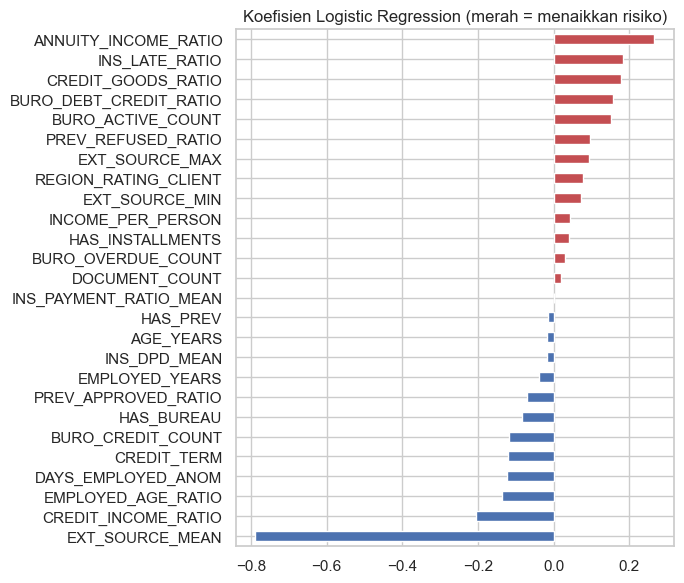

In [27]:
plt.figure(figsize=(7, 6))
coef.plot(kind="barh", color=(coef > 0).map({True: "#c44e52", False: "#4c72b0"}))
plt.title("Koefisien Logistic Regression (merah = menaikkan risiko)")
plt.tight_layout()
plt.show()

Cara baca grafik: tiap batang mewakili satu feature. Batang **merah (koefisien positif)** menaikkan probabilitas default, batang **biru (koefisien negatif)** menurunkannya. Makin panjang batang, makin kuat pengaruhnya. Penekan risiko terkuat adalah `EXT_SOURCE_MEAN` (biru terpanjang), sedangkan penaik risiko terkuat adalah `ANNUITY_INCOME_RATIO` (merah terpanjang).

**Menaikkan risiko (merah), diurutkan dari yang paling kuat:**

- `ANNUITY_INCOME_RATIO` - rasio cicilan tahunan terhadap penghasilan (DTI). Makin besar, beban cicilan makin berat, wajar risikonya naik.
- `INS_LATE_RATIO` - proporsi cicilan yang telat bayar di pinjaman sebelumnya. Sering telat = kebiasaan bayar buruk.
- `CREDIT_GOODS_RATIO` - besar pinjaman dibanding harga barang. Nilai di atas 1 berarti pinjam melebihi harga barang alias uang muka kecil.
- `BURO_DEBT_CREDIT_RATIO` - sisa utang dibanding total plafon di biro kredit. Makin penuh plafonnya, makin berisiko.
- `BURO_ACTIVE_COUNT` - jumlah kredit yang masih aktif di biro. Banyak utang berjalan = beban makin berat.
- `PREV_REFUSED_RATIO` - proporsi aplikasi lampau yang ditolak. Sering ditolak = sinyal buruk.
- `REGION_RATING_CLIENT` - rating wilayah tempat tinggal nasabah (angka lebih besar = wilayah lebih berisiko).
- `BURO_OVERDUE_COUNT` - jumlah kredit yang pernah menunggak di biro kredit.
- `INCOME_PER_PERSON`, `HAS_INSTALLMENTS`, `DOCUMENT_COUNT` - pengaruhnya kecil (batang pendek), hanya sedikit menaikkan risiko.

**Menurunkan risiko (biru), diurutkan dari yang paling kuat:**

- `EXT_SOURCE_MEAN` - rata-rata skor kredit dari sumber eksternal. Skor tinggi = profil kredit bagus. Ini penekan risiko terkuat di seluruh model.
- `CREDIT_INCOME_RATIO` - besar pinjaman dibanding penghasilan (lihat catatan tanda di bawah).
- `EMPLOYED_AGE_RATIO` - proporsi umur hidup yang dihabiskan bekerja. Makin besar = pekerjaan makin stabil.
- `DAYS_EMPLOYED_ANOM` - flag anomali data lama kerja (nilai 365243, biasanya pensiunan atau tidak bekerja).
- `CREDIT_TERM` - proxy tenor (cicilan dibagi pinjaman). Nilai besar = tenor pendek dengan cicilan besar, dan ternyata sedikit menurunkan risiko.
- `BURO_CREDIT_COUNT` dan `HAS_BUREAU` - punya jejak di biro kredit. Adanya track record justru menurunkan risiko.
- `PREV_APPROVED_RATIO` - proporsi aplikasi lampau yang disetujui. Sering disetujui = nasabah baik.
- `EMPLOYED_YEARS` dan `AGE_YEARS` - makin lama bekerja dan makin tua, makin stabil, risikonya turun.
- `HAS_PREV`, `INS_PAYMENT_RATIO_MEAN` - pengaruhnya nyaris nol (batang paling pendek).

## LightGBM

Model ini memakai **set fitur lengkap**. LightGBM menangani non-linear, missing value, dan fitur kategori secara native, dengan early stopping untuk mencegah overfit.

Catatan penting: LightGBM di sini **sengaja tidak memakai `scale_pos_weight`/`is_unbalance`**. Saat dicoba, pembobotan kelas justru membuat model underfit parah (early stopping berhenti di ~iterasi 3, valid AUC hanya ~0.735). Karena metrik kita AUC yang berbasis ranking, pembobotan kelas tidak membantu urutan risiko dan malah merusaknya. Ketidakseimbangan juga tidak perlu ditangani di training: metrik akhir menilai urutan risiko di semua threshold sekaligus, jadi model cukup mengurutkan nasabah dengan benar. Kalaupun nanti butuh keputusan approve/reject di satu titik potong, penanganannya ada di tahap pemilihan threshold berbasis biaya bisnis (lihat bagian Langkah selanjutnya).

In [28]:
X_gb = F.get_lgbm_features(X_all)
X_gb, cat_cols = M._encode_categoricals_for_lgbm(X_gb)
print("Jumlah fitur LGBM:", X_gb.shape[1], "| kolom kategori:", len(cat_cols))
res_gb = M.cross_val_stability("lgbm", X_gb, y, lgbm_params=M.default_lgbm_params(), cat_cols=cat_cols)
sum_gb = M.summarize("LightGBM", res_gb)
sum_gb

Jumlah fitur LGBM: 178 | kolom kategori: 16


  fold 1: train AUC=0.8683  valid AUC=0.7800


  fold 2: train AUC=0.8934  valid AUC=0.7883


  fold 3: train AUC=0.8819  valid AUC=0.7812


  fold 4: train AUC=0.8871  valid AUC=0.7865


  fold 5: train AUC=0.8851  valid AUC=0.7809


{'model': 'LightGBM',
 'oof_auc': 0.78337,
 'oof_gini': 0.56674,
 'oof_ks': 0.42568,
 'oof_pr_auc': 0.27446,
 'cv_valid_auc_mean': 0.78338,
 'cv_valid_auc_std': 0.00335,
 'cv_train_auc_mean': 0.88316,
 'overfit_gap': 0.09978,
 'fold_valid_auc': [0.78, 0.78828, 0.78124, 0.7865, 0.78088]}

## Evaluasi dan stabilitas

Bandingkan kedua model dan tegaskan stabilitasnya (mean vs std AUC antar fold, dan gap train vs valid).

### Tabel ringkasan metrik

Bandingkan angka inti kedua model berdampingan.

In [29]:
summary_df = pd.DataFrame([sum_lr, sum_gb]).set_index("model")
summary_df[["oof_auc", "oof_gini", "oof_ks", "cv_valid_auc_mean", "cv_valid_auc_std", "overfit_gap"]]

,oof_auc,oof_gini,oof_ks,cv_valid_auc_mean,cv_valid_auc_std,overfit_gap
model,,,,,,
Logistic Regression,0.74313,0.48626,0.36322,0.74316,0.00402,0.00037
LightGBM,0.78337,0.56674,0.42568,0.78338,0.00335,0.09978


**Interpretasi** 

LightGBM unggul di semua metrik pembeda: `oof_auc` 0.783 vs 0.743, `oof_gini` 0.567 vs 0.486, dan `oof_ks` 0.426 vs 0.363. Artinya LightGBM jauh lebih tajam memisahkan nasabah default dari yang lancar.

Kedua model sama-sama stabil antar fold: `cv_valid_auc_mean` hampir identik dengan `oof_auc`-nya, dan `cv_valid_auc_std` sangat kecil (0.0034 untuk LightGBM, 0.0040 untuk LogReg), jadi performa tidak melompat-lompat tergantung fold.

Bedanya ada di `overfit_gap` (selisih AUC train vs valid). LogReg nyaris 0 (0.0004), berarti tidak overfit sama sekali, wajar karena modelnya sederhana dan pakai subset fitur interpretable. LightGBM punya gap 0.100: train jelas lebih tinggi dari valid, tapi gap ini masih terkontrol karena hasil valid-nya tetap stabil dan konsisten antar fold (di-rem oleh early stopping), bukan overfit liar.

Kesimpulannya: LightGBM dipilih sebagai model utama karena discriminative power-nya jauh lebih tinggi dengan stabilitas yang tetap terjaga, sementara LogReg tetap berguna sebagai baseline yang sederhana, sangat interpretable, dan bebas overfit.

### Kurva ROC

Kurva ROC memvisualkan kemampuan tiap model membedakan nasabah default vs lancar. Makin ke kiri-atas makin baik.

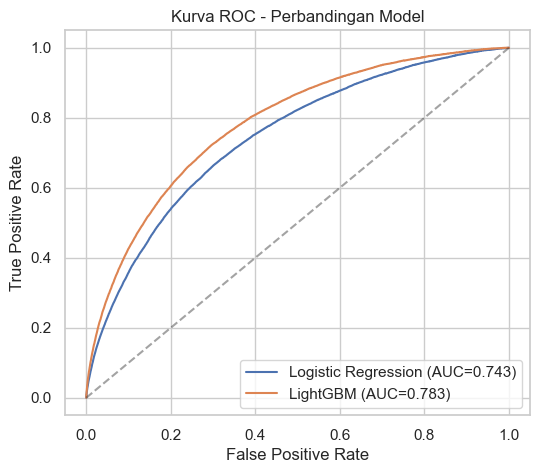

In [30]:
plt.figure(figsize=(6, 5))
for name, res in [("Logistic Regression", res_lr), ("LightGBM", res_gb)]:
    fpr, tpr, _ = roc_curve(y, res["oof_pred"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['oof_auc']:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Kurva ROC - Perbandingan Model")
plt.legend(loc="lower right")
plt.show()

### Stabilitas antar fold

AUC valid di tiap fold dari Stratified 5-Fold. Batang yang tingginya seragam antar fold berarti performa stabil.

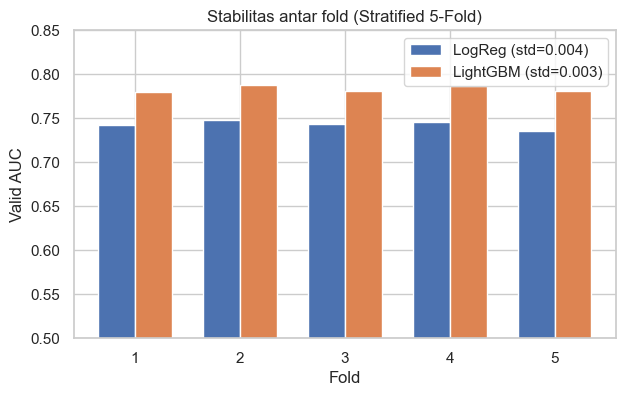

In [31]:
folds = np.arange(1, len(sum_gb["fold_valid_auc"]) + 1)
w = 0.35
plt.figure(figsize=(7, 4))
plt.bar(folds - w/2, sum_lr["fold_valid_auc"], w, label=f"LogReg (std={sum_lr['cv_valid_auc_std']:.3f})")
plt.bar(folds + w/2, sum_gb["fold_valid_auc"], w, label=f"LightGBM (std={sum_gb['cv_valid_auc_std']:.3f})")
plt.ylim(0.5, 0.85)
plt.xticks(folds)
plt.xlabel("Fold")
plt.ylabel("Valid AUC")
plt.title("Stabilitas antar fold (Stratified 5-Fold)")
plt.legend()
plt.show()

Std AUC antar fold yang kecil (LogReg ~0.004, LightGBM ~0.003) menandakan performa stabil, bukan kebetulan bagus di satu split.

 LightGBM punya gap train vs valid sekitar 0.10 (wajar untuk boosting), tapi valid AUC-nya konsisten antar fold, jadi model tidak overfit sampai merusak generalisasi. LogReg gap-nya hampir nol.

## SHAP dan reason codes (Gen AI)

Kita latih satu LightGBM final di seluruh data untuk feature importance, SHAP, dan submission. 

SHAP menjelaskan kontribusi tiap fitur per nasabah, lalu diubah jadi **reason codes** (alasan risiko) dalam Bahasa Indonesia.

 Inti reason code deterministik dari SHAP; opsional dirapikan LLM `qwen2.5:3b` via Ollama.

### Latih LightGBM final

Latih satu model di seluruh data latih, dengan jumlah iterasi = rata-rata `best_iteration` dari kelima fold. Model ini yang dipakai untuk feature importance, SHAP, dan submission.

In [32]:
best_iters = [m.best_iteration_ or m.n_estimators for m in res_gb["models"]]
final_params = M.default_lgbm_params()
final_params["n_estimators"] = int(np.mean(best_iters))
final_gb = lgb.LGBMClassifier(**final_params).fit(X_gb, y, categorical_feature=cat_cols or "auto")
print("n_estimators final:", final_params["n_estimators"])

n_estimators final: 1389


### Feature importance

Fitur mana yang paling banyak dipakai model untuk memisahkan risiko.

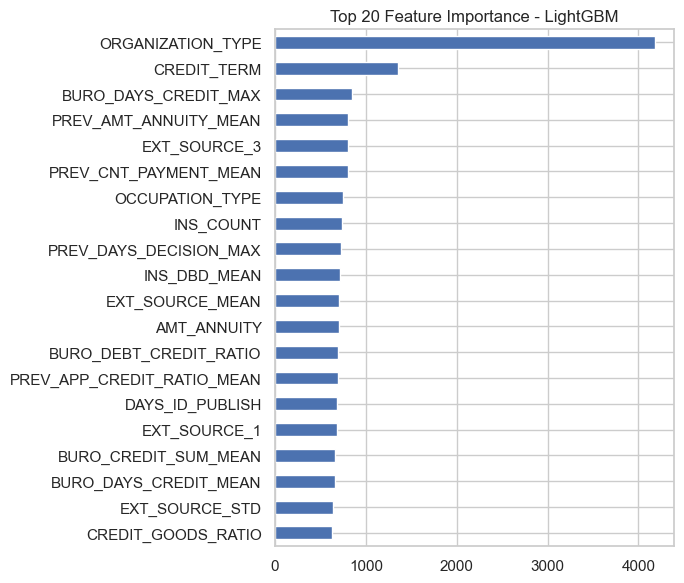

In [33]:
imp = pd.Series(final_gb.feature_importances_, index=X_gb.columns).sort_values(ascending=False).head(20)
plt.figure(figsize=(7, 6))
imp[::-1].plot(kind="barh")
plt.title("Top 20 Feature Importance - LightGBM")
plt.tight_layout()
plt.show()

**Interpretasi (top 3 fitur).**

1. **`ORGANIZATION_TYPE`** paling sering dipakai model. Ini jenis industri/organisasi tempat nasabah bekerja, dipakai sebagai proxy stabilitas pekerjaan dan penghasilan.
2. **`CREDIT_TERM`** (= `AMT_ANNUITY / AMT_CREDIT`) menangkap beban angsuran relatif terhadap total kredit. Makin besar berarti tenor makin pendek / cicilan makin berat per bulan.
3. **`BURO_DAYS_CREDIT_MAX`** dari data biro kredit, menandai seberapa baru kredit terakhir nasabah di lembaga lain.

Perhatian: importance di atas berbasis **split count** (berapa kali fitur dipakai memecah node), yang cenderung membesarkan fitur kategori berkardinalitas tinggi seperti `ORGANIZATION_TYPE` (~58 kategori) hanya karena punya banyak nilai untuk di-split. Jadi grafik ini menunjukkan fitur yang paling *sering dipakai*, belum tentu yang paling *kuat* mendorong risiko. Untuk klaim "pendorong terkuat" yang valid, kita lihat SHAP importance di bawah.

### SHAP importance (pendorong risiko terkuat yang sebenarnya)

SHAP importance = rata-rata besar kontribusi tiap fitur ke prediksi (`mean(|SHAP|)`). Bedanya dengan split-count: SHAP mengukur seberapa besar fitur menggeser prediksi log-odds default, bukan sekadar frekuensi fitur dipakai. Karena itu SHAP tidak bias oleh jumlah kategori, sehingga adil membandingkan fitur numerik seperti `EXT_SOURCE` dengan fitur kategori seperti `ORGANIZATION_TYPE`.

Kita hitung SHAP di sampel acak 3.000 nasabah (cukup untuk ranking yang stabil, jauh lebih cepat daripada seluruh data).

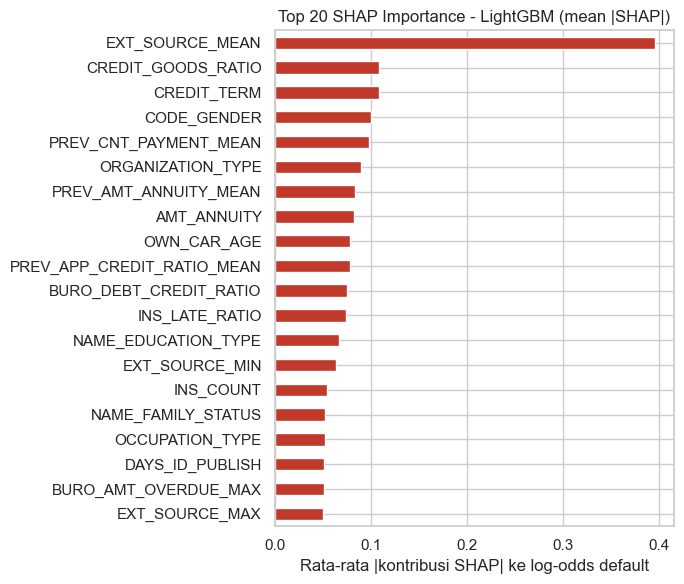

In [34]:
# SHAP importance: rata-rata |kontribusi SHAP| tiap fitur pada sampel nasabah.
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_gb), size=min(3000, len(X_gb)), replace=False)
X_shap = X_gb.iloc[sample_idx]

_, shap_vals = RC.compute_shap_values(final_gb, X_shap)
shap_imp = (pd.Series(np.abs(shap_vals).mean(axis=0), index=X_gb.columns)
              .sort_values(ascending=False).head(20))

plt.figure(figsize=(7, 6))
shap_imp[::-1].plot(kind="barh", color="#c0392b")
plt.title("Top 20 SHAP Importance - LightGBM (mean |SHAP|)")
plt.xlabel("Rata-rata |kontribusi SHAP| ke log-odds default")
plt.tight_layout()
plt.show()

**Interpretasi SHAP.**

- **`EXT_SOURCE_MEAN` mendominasi jauh** (sekitar 4x fitur berikutnya). Skor kredit eksternal adalah pendorong risiko **terkuat** yang sesungguhnya. `EXT_SOURCE_MIN/MAX/1/3` juga ikut muncul di 20 besar, memperkuat bahwa blok skor eksternal adalah sinyal paling menentukan.
- **`ORGANIZATION_TYPE` turun drastis** dari peringkat 1 di split-count ke sekitar peringkat 9 di SHAP. Ini konfirmasi bahwa posisi teratasnya di grafik sebelumnya sebagian besar artefak kardinalitas tinggi, bukan kekuatan prediktif.
- Beban/struktur cicilan (`CREDIT_GOODS_RATIO`, `CREDIT_TERM`) dan disiplin bayar cicilan (`INS_LATE_RATIO`) berada di lapis menengah: berkontribusi nyata, tapi bukan yang terkuat.
- Catatan kepatuhan: `CODE_GENDER` muncul cukup tinggi. Memakai jenis kelamin sebagai faktor keputusan kredit berisiko secara regulasi/etika (diskriminatif). Untuk produksi, fitur ini sebaiknya dievaluasi/di-drop meski menaikkan sedikit performa.

### Arah risiko per ORGANIZATION_TYPE

Feature importance hanya bilang fitur ini penting, bukan arahnya. Untuk melihat tipe organisasi mana yang menaikkan vs menurunkan default, kita lihat langsung default rate (`TARGET` mean) per kategori. Kategori dengan < 500 nasabah dibuang supaya angkanya stabil (tidak bias oleh sampel kecil).

In [35]:
org = app[["ORGANIZATION_TYPE", "TARGET"]].copy()
overall = org["TARGET"].mean()
rate = (org.groupby("ORGANIZATION_TYPE")["TARGET"]
           .agg(default_rate="mean", n="count"))
rate = rate[rate["n"] >= 500].sort_values("default_rate", ascending=False)
rate["default_rate"] = (rate["default_rate"] * 100).round(2)

print(f"Default rate keseluruhan: {overall*100:.2f}%")
print("5 tertinggi (menaikkan default):")
print(rate.head(5).to_string())
print("5 terendah (menurunkan default):")
print(rate.tail(5).to_string())

Default rate keseluruhan: 8.07%
5 tertinggi (menaikkan default):
                   default_rate     n
ORGANIZATION_TYPE                    
Transport: type 3         15.75  1187
Restaurant                11.71  1811
Construction              11.68  6721
Industry: type 1          11.07  1039
Industry: type 3          10.62  3278
5 terendah (menurunkan default):
                     default_rate     n
ORGANIZATION_TYPE                      
Military                     5.13  2634
Police                       5.00  2341
University                   4.90  1327
Security Ministries          4.86  1974
Trade: type 6                4.60   631


### Reason codes per nasabah (Gen AI)

Ambil 5 nasabah dengan prediksi risiko tertinggi, jelaskan kontribusi fitur lewat SHAP, lalu ubah jadi reason codes Bahasa Indonesia (dipoles qwen2.5:3b kalau Ollama aktif, kalau tidak pakai template).

In [36]:
import textwrap

oof = res_gb["oof_pred"]
high_risk_idx = np.argsort(oof)[::-1][:5]
X_sample = X_gb.iloc[high_risk_idx].copy()
prob_sample = oof[high_risk_idx]
reason_list = RC.generate_reason_codes(final_gb, X_sample, prob_sample, top_k=3, use_llm=True)
used_llm = any(r["text_llm"] for r in reason_list)
print("Mode:", "LLM qwen2.5:3b aktif" if used_llm else "template (Ollama tidak aktif)")
for r in reason_list:
    print(f"\nNasabah idx {r['index']} (prob default={r['prob']}):")
    print(textwrap.fill(r["text_final"], width=90, initial_indent="  ", subsequent_indent="  "))

Mode: LLM qwen2.5:3b aktif

Nasabah idx 234374 (prob default=0.9318):
  Pengajuan kredit Anda berisiko karena skor kredit rendah, banyak pinjaman aktif, dan
  total utang di biro kredit cukup besar.

Nasabah idx 138308 (prob default=0.873):
  Pengajuan kredit Anda berisiko karena probabilitas gagal bayar sangat tinggi, sekitar
  87%, dikarenakan skor kredit rendah, baru membuka kredit, dan banyak kredit aktif
  lainnya.

Nasabah idx 48554 (prob default=0.8462):
  Pengajuan kredit Anda berisiko karena probabilitas gagal bayar Anda 0.85, dikarenakan
  skor kredit eksternal rata-rata rendah, total tunggakan di biro kredit cukup besar, dan
  satu dari skor kredit eksternal sangat rendah.

Nasabah idx 209776 (prob default=0.8304):
  Pengajuan kredit Anda berisiko tinggi karena skor kredit Anda rendah, ada tunggakan
  besar di biro kredit, dan satu skor kredit sangat rendah.

Nasabah idx 176416 (prob default=0.8239):
  Pengajuan kredit Anda berisiko karena probabilitas gagal bayar Anda tingg

## Kesimpulan

- Dua model berhasil dibangun: **Logistic Regression** (interpretable, koefisien masuk akal secara bisnis) dan **LightGBM** (boosting, performa lebih tinggi).
- **LightGBM** unggul pada AUC/KS, sedangkan **Logistic Regression** memberi transparansi arah pengaruh tiap fitur.
- **Pendorong risiko terkuat menurut SHAP adalah skor eksternal (`EXT_SOURCE`)**, jauh mendominasi fitur lain. Beban/struktur cicilan, riwayat biro kredit, dan disiplin bayar cicilan ikut berkontribusi di lapis berikutnya. (Split-count LightGBM menaruh `ORGANIZATION_TYPE` di puncak, tapi itu bias kardinalitas; SHAP mengoreksinya.)
- **Stabilitas** ditunjukkan oleh std AUC antar fold yang kecil dan gap train vs valid yang terkendali.
- **Gen AI**: SHAP + LLM mengubah prediksi jadi reason codes yang bisa dijelaskan ke nasabah/analis.

### Langkah selanjutnya (next step)

- Menambah 3 tabel pendukung yang belum dipakai (`POS_CASH_balance`, `credit_card_balance`, `bureau_balance`).
- Penentuan threshold approval berbasis biaya bisnis (trade-off antara menolak nasabah baik vs menerima nasabah berisiko).